n=10, epsilon=0.4295, coverage=0.9976
n=100, epsilon=0.1358, coverage=0.9940
n=1000, epsilon=0.0429, coverage=0.9949
n=10000, epsilon=0.0136, coverage=0.9954


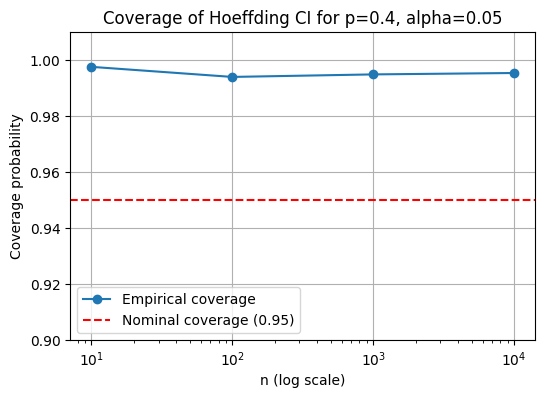

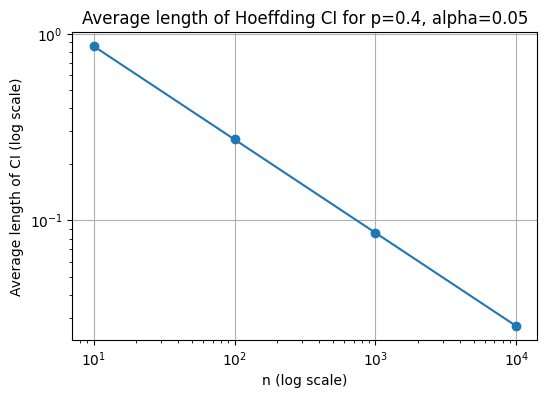

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
alpha = 0.05 
p = 0.4

# draw a sample from bernoulli distribution
reps = 10000
sample_sizes = [10, 100, 1000, 10000]
rng = np.random.default_rng(23)
coverages = []

lengths = []

for n in sample_sizes:
    draws = rng.binomial(1, p, size=(reps,n))

    phats = draws.mean(axis=1)
    eps = np.sqrt((1 / (2 * n)) * np.log(2 / alpha))
    
    # Construct confidence intervals
    lower = phats - eps
    upper = phats + eps

    length = upper - lower
    lengths.append(length.mean())

    covered = (p >= lower) & (p <= upper)
    coverage = covered.mean()

    coverages.append(coverage)

    print(f"n={n}, epsilon={eps:.4f}, coverage={coverage:.4f}") 

plt.figure(figsize=(6,4))
plt.plot(sample_sizes, coverages, marker='o', label='Empirical coverage')
plt.axhline(1 - alpha, color='red', linestyle='--', label='Nominal coverage (0.95)')
plt.xscale('log')
plt.ylim(0.9, 1.01)
plt.xlabel("n (log scale)")
plt.ylabel("Coverage probability")
plt.title(f"Coverage of Hoeffding CI for p={p}, alpha={alpha}")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(sample_sizes, lengths, marker='o')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("n (log scale)")
plt.ylabel("Average length of CI (log scale)")
plt.title(f"Average length of Hoeffding CI for p={p}, alpha={alpha }")
plt.grid(True)
plt.show()